In [11]:
import torch
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


Parasitized: 13779 images
  sample size: (112, 115), mode: RGB
Uninfected: 13779 images
  sample size: (115, 127), mode: RGB


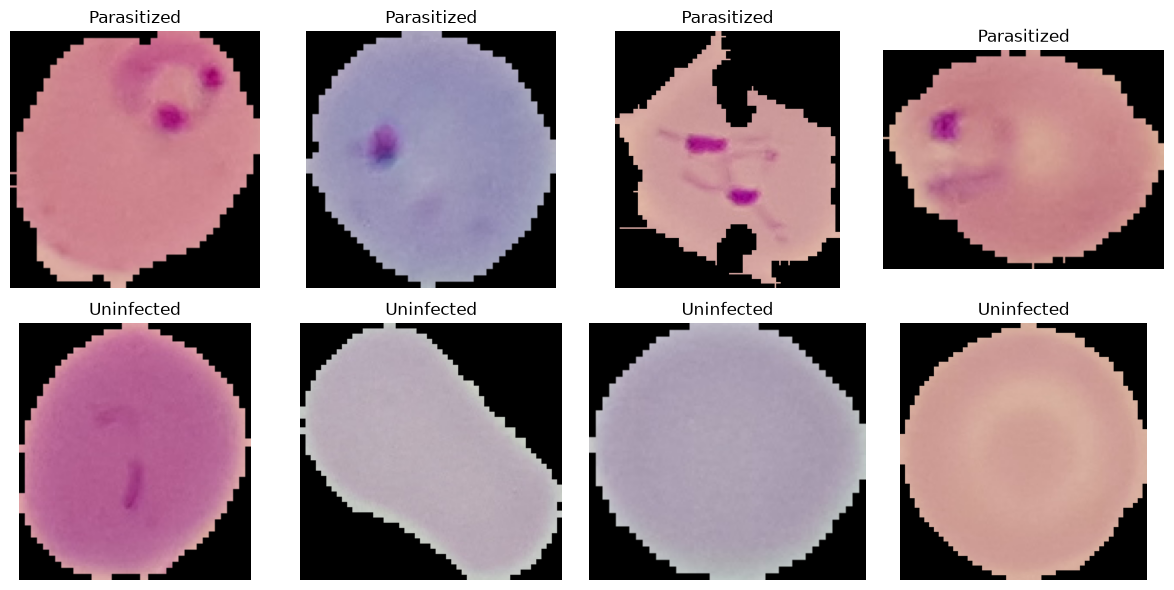

In [12]:
import os
from PIL import Image
import matplotlib.pyplot as plt

data_dir = "cell_images"
classes = ["Parasitized", "Uninfected"]

for c in classes:
    files = os.listdir(os.path.join(data_dir, c))
    files = [f for f in files if f.endswith(".png")]
    print(f"{c}: {len(files)} images")

    # look at one sample image's size
    sample = Image.open(os.path.join(data_dir, c, files[0]))
    print(f"  sample size: {sample.size}, mode: {sample.mode}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(data_dir, c))[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(data_dir, c, f))
        axes[i, j].imshow(img)
        axes[i, j].set_title(c)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

In [13]:
import random
from sklearn.model_selection import train_test_split

random.seed(42)
N_PER_CLASS = 3000 

def sample_paths(class_name, n):
    folder = os.path.join(data_dir, class_name)
    files = [f for f in os.listdir(folder) if f.endswith(".png")]
    chosen = random.sample(files, n)
    return [os.path.join(folder, f) for f in chosen]

parasitized_paths = sample_paths("Parasitized", N_PER_CLASS)
uninfected_paths = sample_paths("Uninfected", N_PER_CLASS)

paths = parasitized_paths + uninfected_paths
labels = [1] * N_PER_CLASS + [0] * N_PER_CLASS  # 1 = parasitized, 0 = uninfected


train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")



Train: 4200, Val: 900, Test: 900


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 64  # small, since cells are already small — keeps training fast

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # converts to [0,1] range automatically, and reshapes to (C,H,W)
])

class MalariaDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = MalariaDataset(train_paths, train_labels, transform)
val_ds = MalariaDataset(val_paths, val_labels, transform)
test_ds = MalariaDataset(test_paths, test_labels, transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

class MalariaCNN(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        self.conv1 = nn.Conv2d(3, base, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(base, base*2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(base*2, base*4, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(base*4 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 64x64 -> 32x32
        x = self.pool(self.relu(self.conv2(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv3(x)))  # 16x16 -> 8x8
        x = x.view(x.size(0), -1)                # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x.squeeze(1)  # raw logits — no sigmoid here

Using device: mps


In [16]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

EPOCHS = 15
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f} acc: {train_acc:.4f} - val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.1044 acc: 0.9648 - val_loss: 0.1089 val_acc: 0.9556
Epoch 2/15 - train_loss: 0.0916 acc: 0.9688 - val_loss: 0.1189 val_acc: 0.9511
Epoch 3/15 - train_loss: 0.0778 acc: 0.9712 - val_loss: 0.1143 val_acc: 0.9567
Epoch 4/15 - train_loss: 0.0716 acc: 0.9774 - val_loss: 0.1244 val_acc: 0.9544
Epoch 5/15 - train_loss: 0.0626 acc: 0.9786 - val_loss: 0.1458 val_acc: 0.9489
Epoch 6/15 - train_loss: 0.0560 acc: 0.9819 - val_loss: 0.1502 val_acc: 0.9522
Epoch 7/15 - train_loss: 0.0492 acc: 0.9810 - val_loss: 0.1633 val_acc: 0.9511
Epoch 8/15 - train_loss: 0.0451 acc: 0.9838 - val_loss: 0.1629 val_acc: 0.9544
Epoch 9/15 - train_loss: 0.0386 acc: 0.9871 - val_loss: 0.1788 val_acc: 0.9500
Epoch 10/15 - train_loss: 0.0428 acc: 0.9843 - val_loss: 0.1815 val_acc: 0.9500
Epoch 11/15 - train_loss: 0.0249 acc: 0.9912 - val_loss: 0.1931 val_acc: 0.9456
Epoch 12/15 - train_loss: 0.0231 acc: 0.9933 - val_loss: 0.2401 val_acc: 0.9433
Epoch 13/15 - train_loss: 0.0168 acc: 0.9945 - va

1-4 = healthy learning, the loss drops fast (from 0.68 to 0.2) and accuracy rises (from 0.67 to 0.94). From epoch 10 onwards, we can see that the loss on validation set bottoms out at epoch 10 (0.146) and then bounces upward and never comes back down while train loss keep dropping and train acc keep rising to 97.7% meanwhile val acc plateaus at 94-95 around epoch 6. The fact that there is a growing gap between test and validation is an usual sig of overfitting. The best model is around 8-10, not 15. training longer just results in momorization of the training instead of generalization. Since it's an easy visual task 94-95% is a strong starting point.

In [17]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, epochs=30, patience=4, save_path="best_model.pt"):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = []

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, train=False)
        history.append((epoch+1, train_loss, train_acc, val_loss, val_acc))
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} acc: {train_acc:.4f} - val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> new best model saved (val_loss={val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    return history

In [18]:
model = MalariaCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_baseline = train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, epochs=30, patience=4, save_path="best_baseline.pt")

Epoch 1/30 - train_loss: 0.6908 acc: 0.5269 - val_loss: 0.6800 val_acc: 0.5589
  -> new best model saved (val_loss=0.6800)
Epoch 2/30 - train_loss: 0.6391 acc: 0.6360 - val_loss: 0.5707 val_acc: 0.7333
  -> new best model saved (val_loss=0.5707)
Epoch 3/30 - train_loss: 0.4734 acc: 0.7960 - val_loss: 0.3435 val_acc: 0.8689
  -> new best model saved (val_loss=0.3435)
Epoch 4/30 - train_loss: 0.2574 acc: 0.9095 - val_loss: 0.1797 val_acc: 0.9367
  -> new best model saved (val_loss=0.1797)
Epoch 5/30 - train_loss: 0.1945 acc: 0.9338 - val_loss: 0.1594 val_acc: 0.9567
  -> new best model saved (val_loss=0.1594)
Epoch 6/30 - train_loss: 0.1867 acc: 0.9414 - val_loss: 0.1697 val_acc: 0.9467
Epoch 7/30 - train_loss: 0.1690 acc: 0.9462 - val_loss: 0.1416 val_acc: 0.9578
  -> new best model saved (val_loss=0.1416)
Epoch 8/30 - train_loss: 0.1573 acc: 0.9493 - val_loss: 0.1422 val_acc: 0.9600
Epoch 9/30 - train_loss: 0.1492 acc: 0.9531 - val_loss: 0.1346 val_acc: 0.9600
  -> new best model saved

Best checkpoint at epoch 8 confirms earlier observation and early stopping fired at epoch 12. 

In [19]:
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

train_ds_aug = MalariaDataset(train_paths, train_labels, train_transform_aug)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)

model_aug = MalariaCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

history_aug = train_with_early_stopping(model_aug, optimizer_aug, criterion, train_loader_aug, val_loader, epochs=30, patience=4, save_path="best_aug.pt")

Epoch 1/30 - train_loss: 0.6516 acc: 0.6033 - val_loss: 0.7216 val_acc: 0.5911
  -> new best model saved (val_loss=0.7216)
Epoch 2/30 - train_loss: 0.4858 acc: 0.7757 - val_loss: 0.4438 val_acc: 0.7933
  -> new best model saved (val_loss=0.4438)
Epoch 3/30 - train_loss: 0.2527 acc: 0.9038 - val_loss: 0.1905 val_acc: 0.9422
  -> new best model saved (val_loss=0.1905)
Epoch 4/30 - train_loss: 0.2073 acc: 0.9340 - val_loss: 0.1686 val_acc: 0.9511
  -> new best model saved (val_loss=0.1686)
Epoch 5/30 - train_loss: 0.1891 acc: 0.9410 - val_loss: 0.1578 val_acc: 0.9522
  -> new best model saved (val_loss=0.1578)
Epoch 6/30 - train_loss: 0.1787 acc: 0.9476 - val_loss: 0.1581 val_acc: 0.9511
Epoch 7/30 - train_loss: 0.1717 acc: 0.9448 - val_loss: 0.1481 val_acc: 0.9489
  -> new best model saved (val_loss=0.1481)
Epoch 8/30 - train_loss: 0.1597 acc: 0.9502 - val_loss: 0.1458 val_acc: 0.9567
  -> new best model saved (val_loss=0.1458)
Epoch 9/30 - train_loss: 0.1556 acc: 0.9517 - val_loss: 0.13

Best checkpoint at epoch 27, ran full 30 epochs without early stoppint ever triggering.

In [20]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

results_size = {}

for name, base in [("reduced", 8), ("standard", 16)]:
    print(f"\n--- {name} (base={base}) ---")
    model = MalariaCNN(base=base).to(device)
    print(f"Total parameters: {count_params(model):,}")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    history = train_with_early_stopping(
        model, optimizer, criterion, train_loader_aug, val_loader,
        epochs=30, patience=4, save_path=f"best_{name}.pt"
    )
    results_size[name] = history


--- reduced (base=8) ---
Total parameters: 268,433
Epoch 1/30 - train_loss: 0.6873 acc: 0.5383 - val_loss: 0.6724 val_acc: 0.5967
  -> new best model saved (val_loss=0.6724)
Epoch 2/30 - train_loss: 0.6127 acc: 0.6667 - val_loss: 0.5848 val_acc: 0.7256
  -> new best model saved (val_loss=0.5848)
Epoch 3/30 - train_loss: 0.5116 acc: 0.7657 - val_loss: 0.4837 val_acc: 0.8011
  -> new best model saved (val_loss=0.4837)
Epoch 4/30 - train_loss: 0.3838 acc: 0.8364 - val_loss: 0.2875 val_acc: 0.8844
  -> new best model saved (val_loss=0.2875)
Epoch 5/30 - train_loss: 0.2711 acc: 0.8845 - val_loss: 0.2042 val_acc: 0.9089
  -> new best model saved (val_loss=0.2042)
Epoch 6/30 - train_loss: 0.2289 acc: 0.8993 - val_loss: 0.1765 val_acc: 0.9233
  -> new best model saved (val_loss=0.1765)
Epoch 7/30 - train_loss: 0.2024 acc: 0.9190 - val_loss: 0.1711 val_acc: 0.9344
  -> new best model saved (val_loss=0.1711)
Epoch 8/30 - train_loss: 0.1918 acc: 0.9257 - val_loss: 0.1599 val_acc: 0.9467
  -> new

In [21]:
results_lr = {}

for lr in [1e-3, 1e-4, 1e-5]:
    print(f"\n--- lr={lr} ---")
    model = MalariaCNN(base=16).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = train_with_early_stopping(
        model, optimizer, criterion, train_loader_aug, val_loader,
        epochs=30, patience=4, save_path=f"best_lr_{lr}.pt"
    )
    results_lr[lr] = history


--- lr=0.001 ---
Epoch 1/30 - train_loss: 0.6791 acc: 0.5583 - val_loss: 0.6435 val_acc: 0.6467
  -> new best model saved (val_loss=0.6435)
Epoch 2/30 - train_loss: 0.6197 acc: 0.6619 - val_loss: 0.5685 val_acc: 0.7400
  -> new best model saved (val_loss=0.5685)
Epoch 3/30 - train_loss: 0.5002 acc: 0.7595 - val_loss: 0.3491 val_acc: 0.8522
  -> new best model saved (val_loss=0.3491)
Epoch 4/30 - train_loss: 0.2578 acc: 0.8967 - val_loss: 0.2209 val_acc: 0.9256
  -> new best model saved (val_loss=0.2209)
Epoch 5/30 - train_loss: 0.2148 acc: 0.9324 - val_loss: 0.1813 val_acc: 0.9433
  -> new best model saved (val_loss=0.1813)
Epoch 6/30 - train_loss: 0.1825 acc: 0.9395 - val_loss: 0.1713 val_acc: 0.9456
  -> new best model saved (val_loss=0.1713)
Epoch 7/30 - train_loss: 0.1808 acc: 0.9405 - val_loss: 0.1584 val_acc: 0.9433
  -> new best model saved (val_loss=0.1584)
Epoch 8/30 - train_loss: 0.1695 acc: 0.9464 - val_loss: 0.1555 val_acc: 0.9500
  -> new best model saved (val_loss=0.1555

In [22]:
model_1e3 = MalariaCNN(base=16).to(device)
optimizer_1e3 = optim.Adam(model_1e3.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

history_1e3_extended = train_with_early_stopping(
    model_1e3, optimizer_1e3, criterion, train_loader_aug, val_loader,
    epochs=60, patience=6, save_path="best_lr_1e-3_extended.pt"
)

model_1e4 = MalariaCNN(base=16).to(device)
optimizer_1e4 = optim.Adam(model_1e4.parameters(), lr=1e-4)

history_1e4_extended = train_with_early_stopping(
    model_1e4, optimizer_1e4, criterion, train_loader_aug, val_loader,
    epochs=60, patience=6, save_path="best_lr_1e-4_extended.pt"
)

Epoch 1/60 - train_loss: 0.6798 acc: 0.5619 - val_loss: 0.6503 val_acc: 0.6156
  -> new best model saved (val_loss=0.6503)
Epoch 2/60 - train_loss: 0.6241 acc: 0.6588 - val_loss: 0.5539 val_acc: 0.7211
  -> new best model saved (val_loss=0.5539)
Epoch 3/60 - train_loss: 0.4676 acc: 0.8000 - val_loss: 0.3624 val_acc: 0.9056
  -> new best model saved (val_loss=0.3624)
Epoch 4/60 - train_loss: 0.2668 acc: 0.8976 - val_loss: 0.2061 val_acc: 0.9111
  -> new best model saved (val_loss=0.2061)
Epoch 5/60 - train_loss: 0.2231 acc: 0.9169 - val_loss: 0.1786 val_acc: 0.9444
  -> new best model saved (val_loss=0.1786)
Epoch 6/60 - train_loss: 0.2100 acc: 0.9283 - val_loss: 0.1771 val_acc: 0.9356
  -> new best model saved (val_loss=0.1771)
Epoch 7/60 - train_loss: 0.2003 acc: 0.9274 - val_loss: 0.1724 val_acc: 0.9389
  -> new best model saved (val_loss=0.1724)
Epoch 8/60 - train_loss: 0.1915 acc: 0.9343 - val_loss: 0.1730 val_acc: 0.9433
Epoch 9/60 - train_loss: 0.1902 acc: 0.9386 - val_loss: 0.15

In [24]:
results_dropout = {}

for dp in [0.0, 0.1, 0.3, 0.5]:
    print(f"\n--- dropout={dp} ---")
    model = MalariaCNN(base=16).to(device)
    model.dropout = nn.Dropout(dp)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    history = train_with_early_stopping(
        model, optimizer, criterion, train_loader_aug, val_loader,
        epochs=40, patience=6, save_path=f"best_dropout_{dp}.pt"
    )
    results_dropout[dp] = history


--- dropout=0.0 ---
Epoch 1/40 - train_loss: 0.6926 acc: 0.5026 - val_loss: 0.6930 val_acc: 0.5000
  -> new best model saved (val_loss=0.6930)
Epoch 2/40 - train_loss: 0.6712 acc: 0.5829 - val_loss: 0.6706 val_acc: 0.5578
  -> new best model saved (val_loss=0.6706)
Epoch 3/40 - train_loss: 0.6295 acc: 0.6460 - val_loss: 0.5410 val_acc: 0.7322
  -> new best model saved (val_loss=0.5410)
Epoch 4/40 - train_loss: 0.4201 acc: 0.8024 - val_loss: 0.3172 val_acc: 0.8889
  -> new best model saved (val_loss=0.3172)
Epoch 5/40 - train_loss: 0.2245 acc: 0.9152 - val_loss: 0.1991 val_acc: 0.9400
  -> new best model saved (val_loss=0.1991)
Epoch 6/40 - train_loss: 0.1872 acc: 0.9390 - val_loss: 0.1845 val_acc: 0.9444
  -> new best model saved (val_loss=0.1845)
Epoch 7/40 - train_loss: 0.1738 acc: 0.9469 - val_loss: 0.1794 val_acc: 0.9322
  -> new best model saved (val_loss=0.1794)
Epoch 8/40 - train_loss: 0.1604 acc: 0.9479 - val_loss: 0.1803 val_acc: 0.9422
Epoch 9/40 - train_loss: 0.1641 acc: 0.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)  
        focal_weight = self.alpha * (1 - p_t) ** self.gamma
        loss = focal_weight * bce_loss
        return loss.mean()

In [26]:
model_focal = MalariaCNN(base=16).to(device)
model_focal.dropout = nn.Dropout(0.3)
optimizer_focal = optim.Adam(model_focal.parameters(), lr=1e-3)
criterion_focal = FocalLoss(alpha=0.25, gamma=2.0)

history_focal = train_with_early_stopping(
    model_focal, optimizer_focal, criterion_focal, train_loader_aug, val_loader,
    epochs=40, patience=6, save_path="best_focal.pt"
)

Epoch 1/40 - train_loss: 0.0418 acc: 0.5890 - val_loss: 0.0395 val_acc: 0.6411
  -> new best model saved (val_loss=0.0395)
Epoch 2/40 - train_loss: 0.0361 acc: 0.7129 - val_loss: 0.0323 val_acc: 0.7778
  -> new best model saved (val_loss=0.0323)
Epoch 3/40 - train_loss: 0.0208 acc: 0.8738 - val_loss: 0.0127 val_acc: 0.9378
  -> new best model saved (val_loss=0.0127)
Epoch 4/40 - train_loss: 0.0129 acc: 0.9407 - val_loss: 0.0143 val_acc: 0.9344
Epoch 5/40 - train_loss: 0.0118 acc: 0.9474 - val_loss: 0.0102 val_acc: 0.9489
  -> new best model saved (val_loss=0.0102)
Epoch 6/40 - train_loss: 0.0108 acc: 0.9510 - val_loss: 0.0100 val_acc: 0.9467
  -> new best model saved (val_loss=0.0100)
Epoch 7/40 - train_loss: 0.0108 acc: 0.9483 - val_loss: 0.0106 val_acc: 0.9422
Epoch 8/40 - train_loss: 0.0102 acc: 0.9529 - val_loss: 0.0090 val_acc: 0.9489
  -> new best model saved (val_loss=0.0090)
Epoch 9/40 - train_loss: 0.0103 acc: 0.9543 - val_loss: 0.0087 val_acc: 0.9489
  -> new best model saved

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        output = self.model(input_tensor) 
        self.model.zero_grad()
        output.backward()

     
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)  
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8) 
        return cam

Saved: gradcam_outputs/parasitized_0.png
Saved: gradcam_outputs/parasitized_1.png
Saved: gradcam_outputs/parasitized_2.png
Saved: gradcam_outputs/parasitized_3.png
Saved: gradcam_outputs/parasitized_4.png


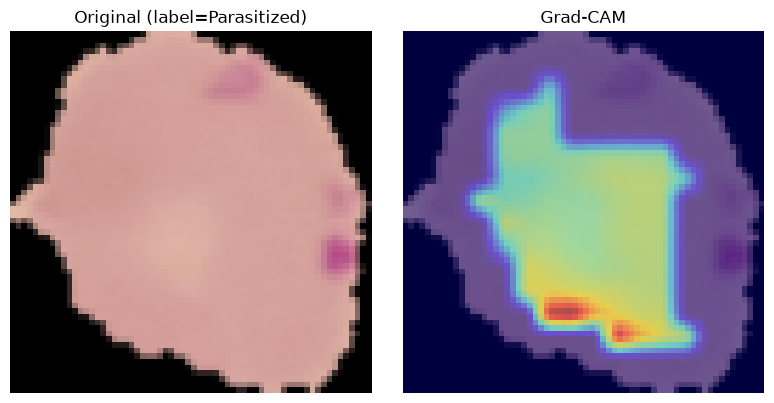

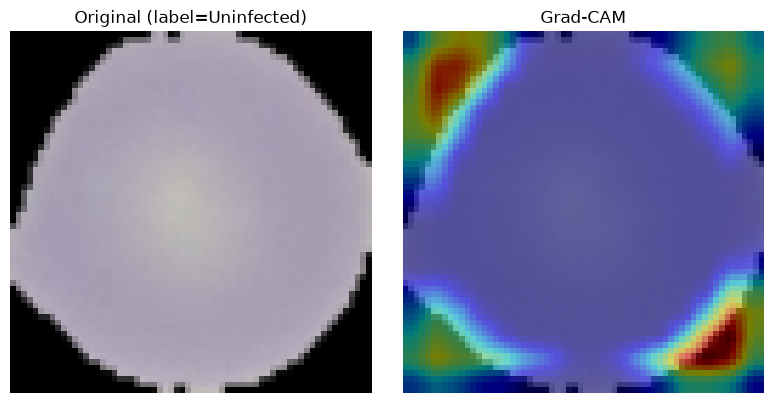

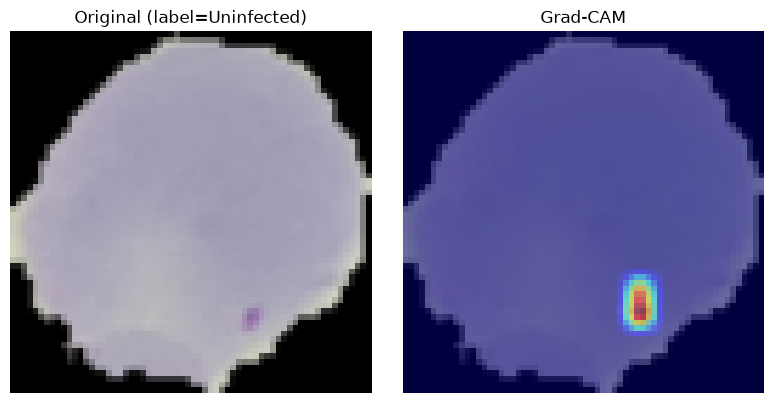

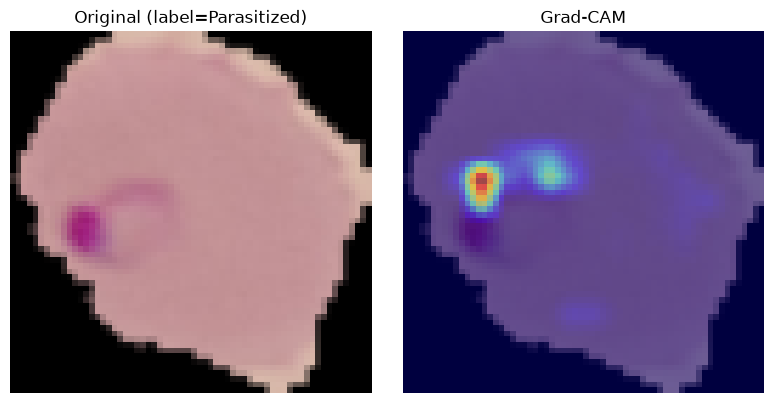

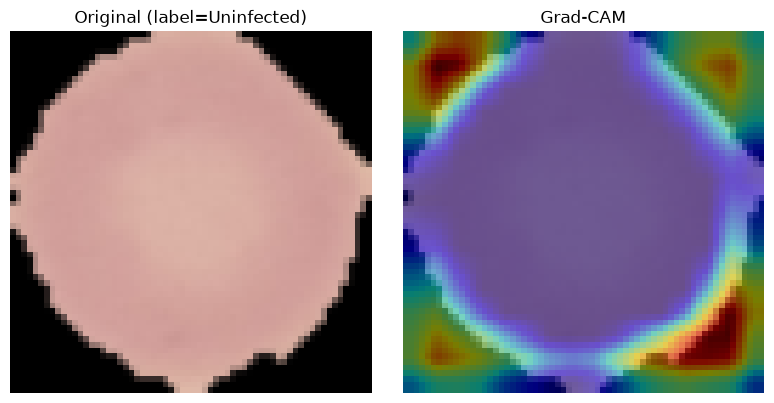

In [38]:
import cv2

final_model = MalariaCNN(base=16).to(device)
final_model.dropout = nn.Dropout(0.3)
final_model.load_state_dict(torch.load("best_dropout_0.3.pt"))  # your BCE+dropout=0.3 checkpoint

cam_extractor = GradCAM(final_model, final_model.conv3)

def show_gradcam(idx, dataset, save_path=None):
    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = False

    cam = cam_extractor.generate(input_tensor)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    img_np = img_tensor.permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original (label={'Parasitized' if label==1 else 'Uninfected'})")
    axes[0].axis("off")

    axes[1].imshow(img_np)
    axes[1].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")


# Show a few parasitized examples from the test set
for i in range(5):
    idx = test_labels.index(1) + i  # crude way to grab a few parasitized samples
    show_gradcam(idx, test_ds, save_path=f"gradcam_outputs/parasitized_{i}.png")

Saved: gradcam_outputs/parasitized_0.png


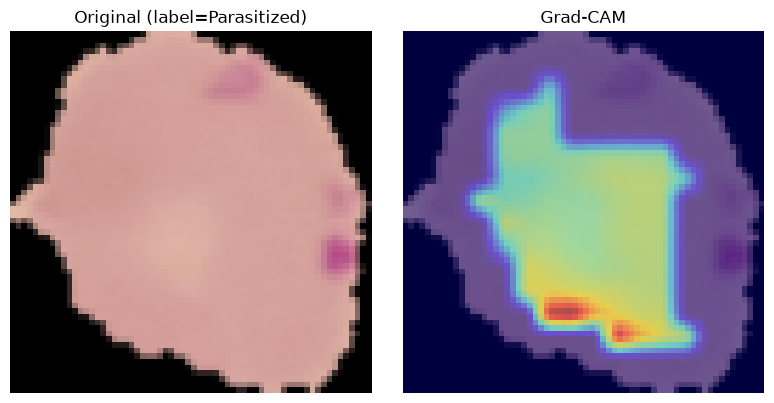

Saved: gradcam_outputs/parasitized_1.png


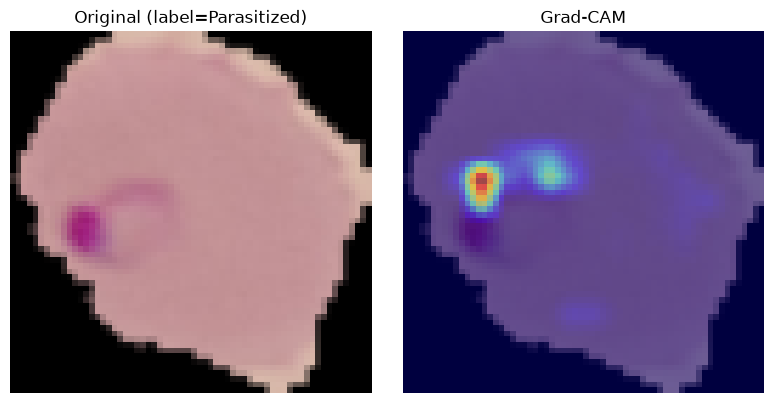

Saved: gradcam_outputs/parasitized_2.png


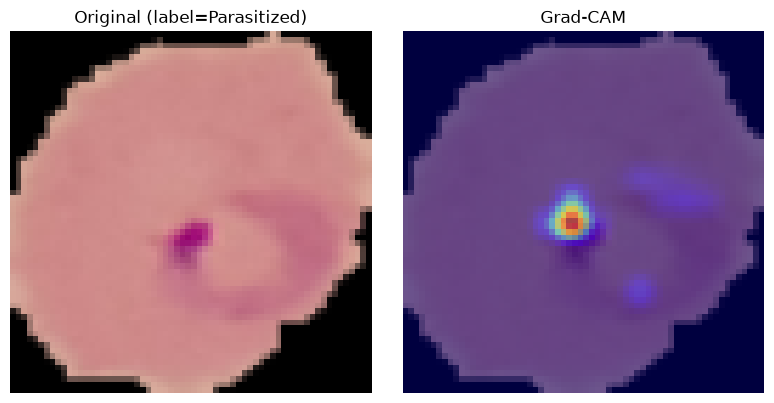

Saved: gradcam_outputs/parasitized_3.png


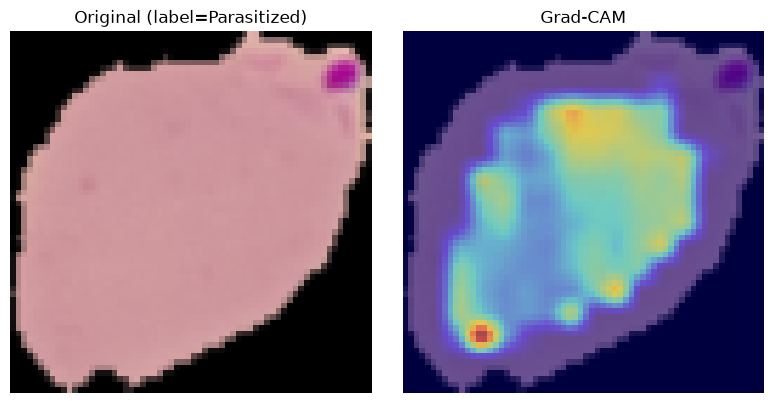

Saved: gradcam_outputs/parasitized_4.png


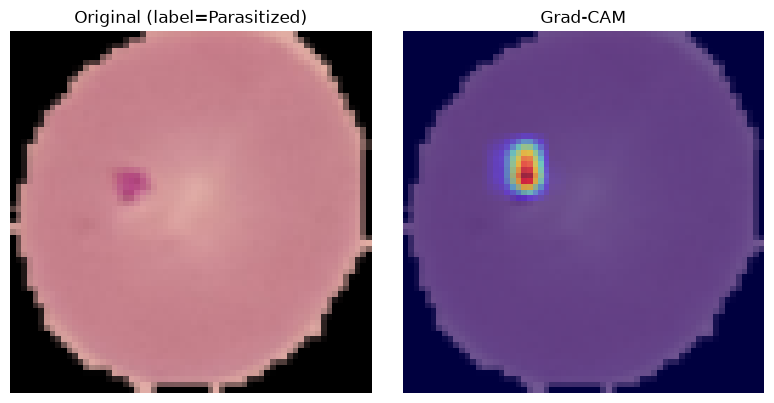

Saved: gradcam_outputs/uninfected_0.png


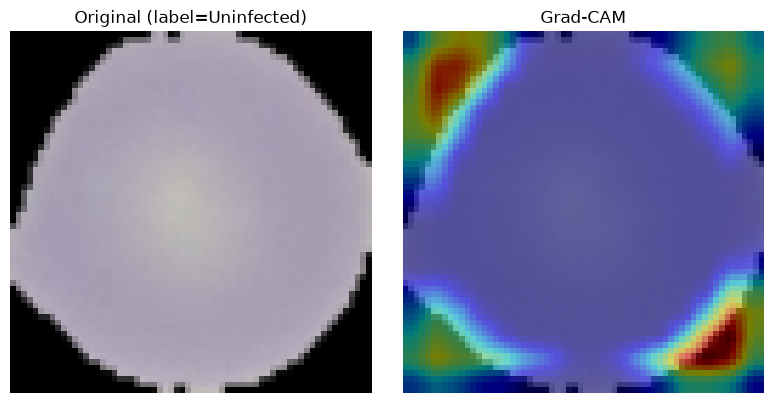

Saved: gradcam_outputs/uninfected_1.png


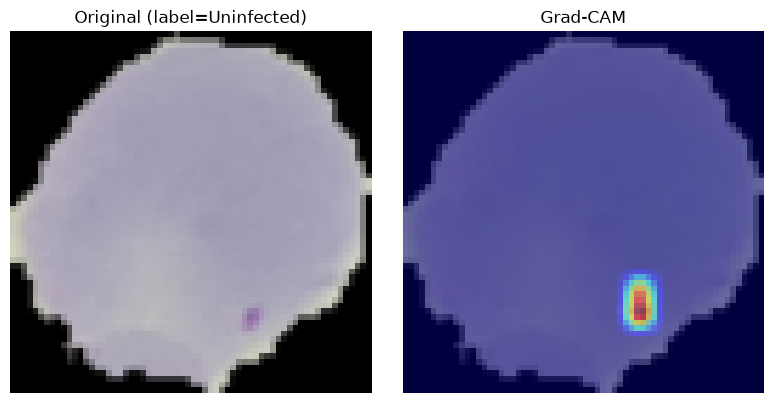

Saved: gradcam_outputs/uninfected_2.png


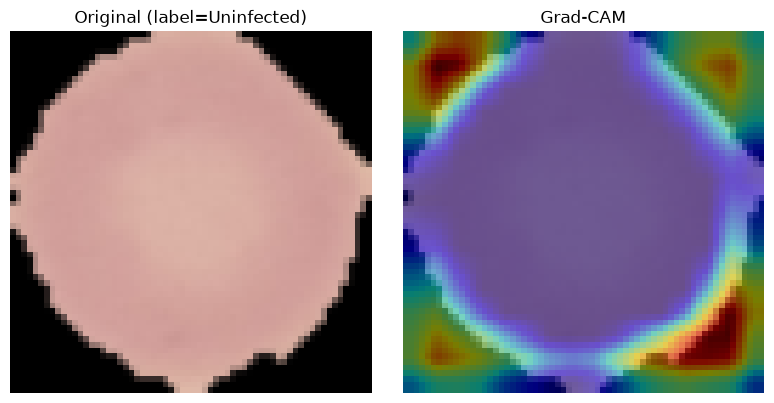

Saved: gradcam_outputs/uninfected_3.png


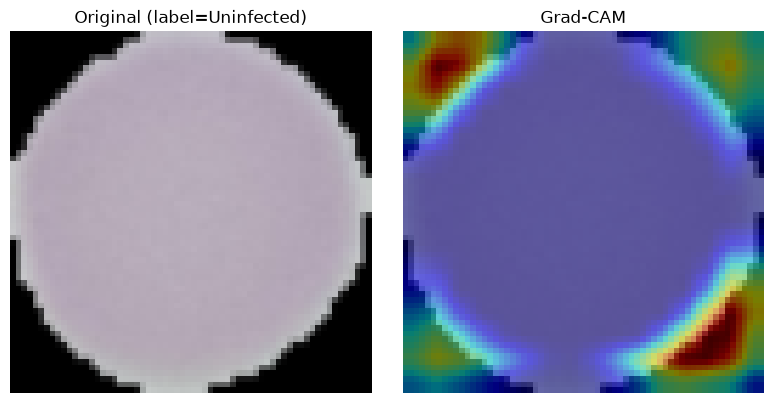

Saved: gradcam_outputs/uninfected_4.png


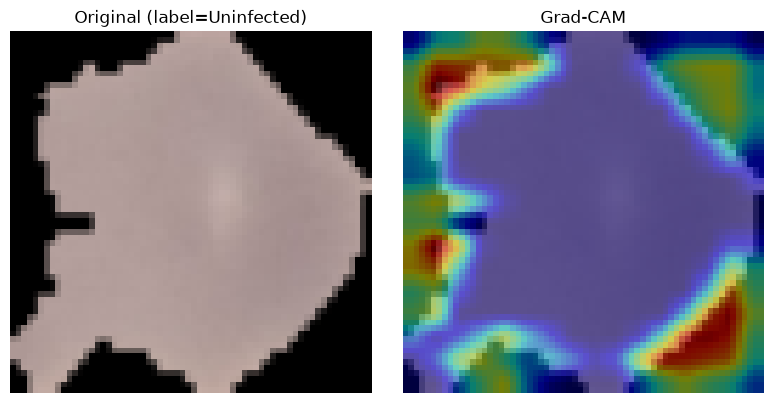

In [36]:
parasitized_indices = [i for i, l in enumerate(test_labels) if l == 1]
uninfected_indices = [i for i, l in enumerate(test_labels) if l == 0]

for i, idx in enumerate(parasitized_indices[:5]):
    show_gradcam(idx, test_ds, save_path=f"gradcam_outputs/parasitized_{i}.png")

for i, idx in enumerate(uninfected_indices[:5]):
    show_gradcam(idx, test_ds, save_path=f"gradcam_outputs/uninfected_{i}.png")

In [ ]:
import numpy as np

def has_dark_spot(path, cell_thresh=30, spot_relative_drop=60, min_pixels=8):
    img = np.array(Image.open(path).convert("RGB")).astype(int)
    brightness = img.sum(axis=2)

    cell_mask = brightness > cell_thresh  
    if cell_mask.sum() < 100:  
        return False
    
    cell_pixel_values = brightness[cell_mask]
    median_brightness = np.median(cell_pixel_values)

    dark_spot_pixels = cell_mask & (brightness < median_brightness - spot_relative_drop)
    return dark_spot_pixels.sum() >= min_pixels

flagged = [p for p in uninfected_paths[:500] if has_dark_spot(p)]
print(f"{len(flagged)} / 500 uninfected images flagged as having a suspicious dark spot")

70 / 500 uninfected images flagged as having a suspicious dark spot


In [ ]:
print("Known suspicious image:", has_dark_spot(test_paths[suspicious_idx]))  


print("Should likely be False:", has_dark_spot(uninfected_paths[10]))
print("Should likely be False:", has_dark_spot(uninfected_paths[20]))

Known suspicious image: True
Should likely be False: False
Should likely be False: False


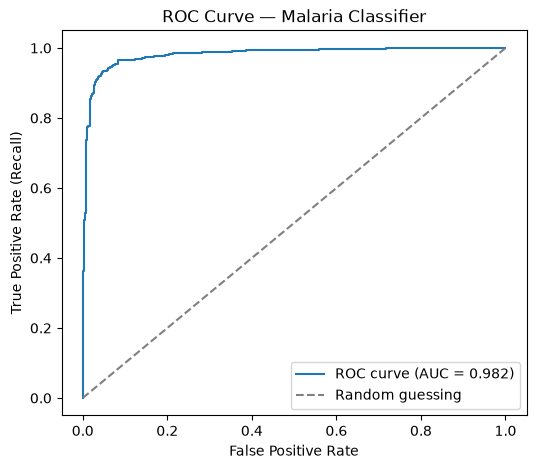

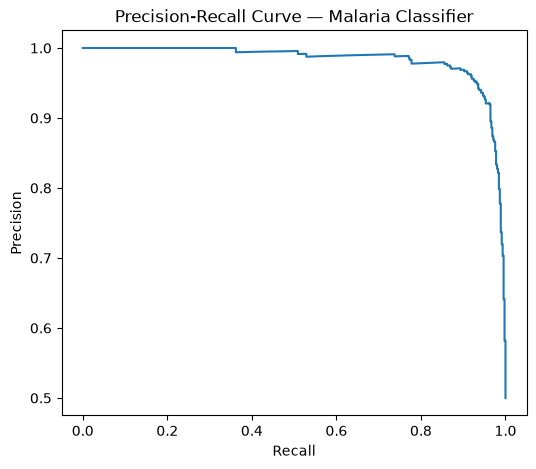

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve


final_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Malaria Classifier")
plt.legend()
plt.savefig("gradcam_outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Malaria Classifier")
plt.savefig("gradcam_outputs/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
for thresh in [0.5, 0.4, 0.3, 0.2, 0.1]:
    preds = (all_probs > thresh).astype(float)
    tp = ((preds == 1) & (all_labels == 1)).sum()
    fn = ((preds == 0) & (all_labels == 1)).sum()
    fp = ((preds == 1) & (all_labels == 0)).sum()
    tn = ((preds == 0) & (all_labels == 0)).sum()
    recall_val = tp / (tp + fn)
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"Threshold {thresh:.1f}: Recall={recall_val:.3f}, Precision={precision_val:.3f}, "
          f"Missed infections (FN)={fn}, False alarms (FP)={fp}")

Threshold 0.5: Recall=0.942, Precision=0.938, Missed infections (FN)=26, False alarms (FP)=28
Threshold 0.4: Recall=0.947, Precision=0.936, Missed infections (FN)=24, False alarms (FP)=29
Threshold 0.3: Recall=0.953, Precision=0.921, Missed infections (FN)=21, False alarms (FP)=37
Threshold 0.2: Recall=0.964, Precision=0.902, Missed infections (FN)=16, False alarms (FP)=47
Threshold 0.1: Recall=0.976, Precision=0.859, Missed infections (FN)=11, False alarms (FP)=72


In [49]:
seeds = [0, 1, 2]
results_seeds = {}

for seed in seeds:
    print(f"\n--- seed={seed} ---")
    torch.manual_seed(seed)

    model = MalariaCNN(base=16).to(device)
    model.dropout = nn.Dropout(0.3)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    history = train_with_early_stopping(
        model, optimizer, criterion, train_loader_aug, val_loader,
        epochs=40, patience=6, save_path=f"best_seed_{seed}.pt"
    )
    results_seeds[seed] = history


--- seed=0 ---
Epoch 1/40 - train_loss: 0.6719 acc: 0.5793 - val_loss: 0.6337 val_acc: 0.6544
  -> new best model saved (val_loss=0.6337)
Epoch 2/40 - train_loss: 0.5782 acc: 0.7119 - val_loss: 0.5085 val_acc: 0.7833
  -> new best model saved (val_loss=0.5085)
Epoch 3/40 - train_loss: 0.4011 acc: 0.8443 - val_loss: 0.3188 val_acc: 0.8411
  -> new best model saved (val_loss=0.3188)
Epoch 4/40 - train_loss: 0.2426 acc: 0.9019 - val_loss: 0.1871 val_acc: 0.9333
  -> new best model saved (val_loss=0.1871)
Epoch 5/40 - train_loss: 0.2046 acc: 0.9255 - val_loss: 0.1592 val_acc: 0.9467
  -> new best model saved (val_loss=0.1592)
Epoch 6/40 - train_loss: 0.1896 acc: 0.9390 - val_loss: 0.1517 val_acc: 0.9533
  -> new best model saved (val_loss=0.1517)
Epoch 7/40 - train_loss: 0.1807 acc: 0.9440 - val_loss: 0.1601 val_acc: 0.9511
Epoch 8/40 - train_loss: 0.1740 acc: 0.9467 - val_loss: 0.1383 val_acc: 0.9589
  -> new best model saved (val_loss=0.1383)
Epoch 9/40 - train_loss: 0.1594 acc: 0.9505 

In [ ]:
for seed, history in results_seeds.items():
    best = min(history, key=lambda h: h[3]) 
    print(f"seed={seed}: best val_loss={best[3]:.4f}, val_acc={best[4]:.4f} (epoch {best[0]})")

seed=0: best val_loss=0.1055, val_acc=0.9567 (epoch 26)
seed=1: best val_loss=0.1025, val_acc=0.9600 (epoch 28)
seed=2: best val_loss=0.1031, val_acc=0.9589 (epoch 32)
